In [17]:
# Welch’s Method — Compare Different Time Periods
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
# --- Load & prepare data ---
with open("local_path.txt", "r") as f:
    data_path = f.read().strip()  # strip removes \n or spaces

print("Your path is:", data_path)


Your path is: C:/Users/sahrizvi/0. Transaction/OpTransactionHistoryFrom_Oct-24toOct-25.csv


deposit    | 2024-10-01 → 2025-01-01 | Dominant Period ≈ 6.4 days
deposit    | 2025-01-01 → 2025-04-01 | Dominant Period ≈ 32.0 days
deposit    | 2025-04-01 → 2025-07-01 | Dominant Period ≈ 10.7 days
deposit    | 2025-07-01 → 2025-10-01 | Dominant Period ≈ 4.0 days


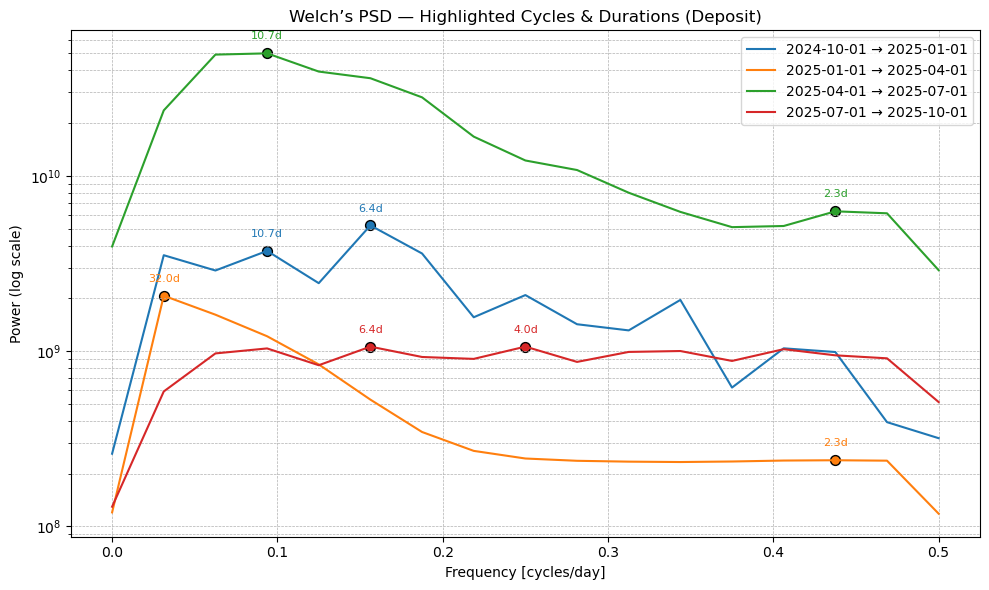

In [18]:

path = data_path
df = pd.read_csv(path)

df = df[["Transaction Date","Withdrawal Amount(INR)","Balance(INR)","Deposit Amount(INR)"]].rename(columns={
    "Transaction Date":"date",
    "Withdrawal Amount(INR)":"withdrawal",
    "Balance(INR)":"balance",
    "Deposit Amount(INR)":"deposit"
}).dropna()

df['date'] = pd.to_datetime(df['date'], format='%d,%m,%Y')
df['is_txn'] = ((df['withdrawal'] > 0) | (df['deposit'] > 0)).astype(int)

daily = (
    df.groupby('date')
      .agg({'balance':'last', 'withdrawal':'sum', 'deposit':'sum', 'is_txn':'sum'})
      .rename(columns={'is_txn':'txn_cnt'})
      .reset_index()
      .rename(columns={'date':'ds', 'balance':'y'})
      .sort_values('ds')
)

fs = 1  # 1 sample per day
nperseg, noverlap = 32, 16
col = 'deposit'  # choose feature: deposit, withdrawal, or y(balance)

# --- Define time windows (3-month rolling) ---
daily = daily.set_index('ds').asfreq('D').interpolate()
windows = [
    ('2024-10-01', '2025-01-01'),
    ('2025-01-01', '2025-04-01'),
    ('2025-04-01', '2025-07-01'),
    ('2025-07-01', '2025-10-01')
]

plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i, (start, end) in enumerate(windows):
    sub = daily.loc[start:end, col].dropna()
    if len(sub) < nperseg:
        print(f"Skipping {start} → {end}: not enough data ({len(sub)} days)")
        continue

    # --- Welch PSD ---
    freqs, psd = welch(sub.values, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    plt.semilogy(freqs, psd, label=f"{start} → {end}", color=colors[i])

    # --- Find top peaks ---
    peaks, _ = find_peaks(psd, distance=2)
    if len(peaks) == 0:
        continue

    top_peaks = peaks[np.argsort(psd[peaks])[-2:]]  # top 2 peaks
    for p in top_peaks:
        period = 1 / freqs[p]
        power = psd[p]
        plt.scatter(freqs[p], power, color=colors[i], s=50, edgecolor='black')
        plt.text(freqs[p], power * 1.2, f"{period:.1f}d", color=colors[i], fontsize=8, ha='center')

    # --- Dominant Period (highest PSD) ---
    dom_period = 1 / freqs[np.argmax(psd)]
    print(f"{col:10s} | {start} → {end} | Dominant Period ≈ {dom_period:.1f} days")

# --- Plot Styling ---
plt.title(f"Welch’s PSD — Highlighted Cycles & Durations ({col.capitalize()})")
plt.xlabel("Frequency [cycles/day]")
plt.ylabel("Power (log scale)")
plt.legend()
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()


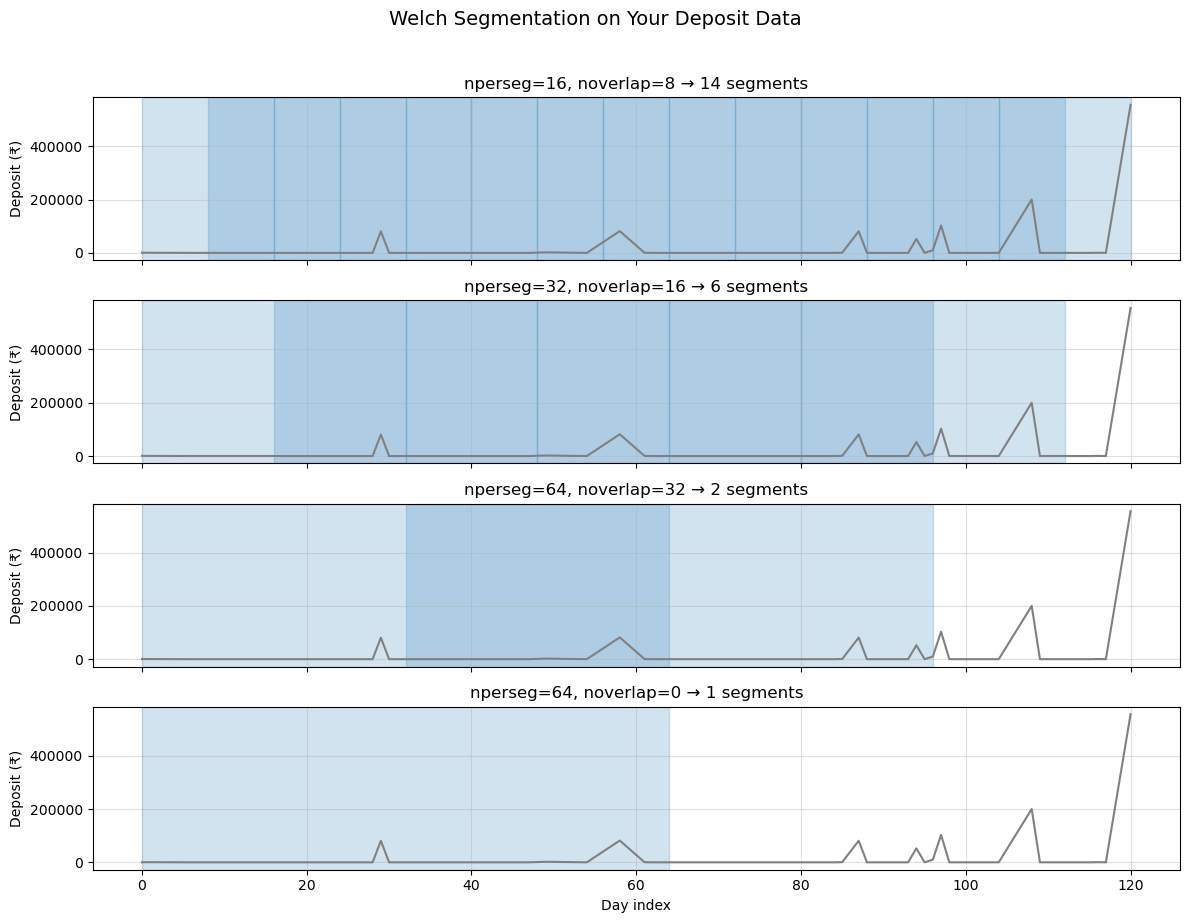

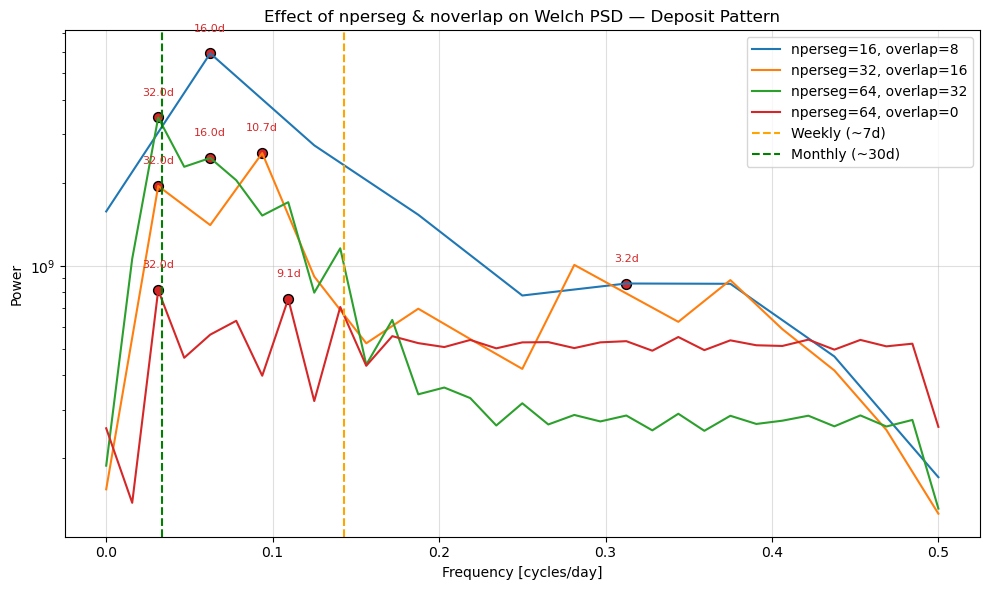

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

path = data_path
df = pd.read_csv(path)

df = df[["Transaction Date","Withdrawal Amount(INR)","Balance(INR)","Deposit Amount(INR)"]].rename(columns={
    "Transaction Date":"date",
    "Withdrawal Amount(INR)":"withdrawal",
    "Balance(INR)":"balance",
    "Deposit Amount(INR)":"deposit"
}).dropna()

df["date"] = pd.to_datetime(df["date"], format="%d,%m,%Y")

# Aggregate daily totals
daily = (
    df.groupby("date")
      .agg({"deposit":"sum"})
      .rename(columns={"deposit":"y"})
      .reset_index()
      .sort_values("date")
)

# Reindex daily to fill missing dates (important for PSD)
daily = daily.set_index("date").asfreq("D").interpolate()

start_date, end_date = '2025-01-01', '2025-05-01'
daily = daily.loc[start_date: end_date]

signal = daily["y"].values
days = np.arange(len(signal))

# --- Step 2: Define Welch settings you want to visualize ---
# dates = ['2024-10-01', '2025-01-01']
settings = [
    (16, 8),
    (32, 16),
    (64, 32),
    (64, 0)  # example of no overlap
]

# --- Step 3: Visualize segmentation on your data ---
fig, axes = plt.subplots(len(settings), 1, figsize=(12, 9), sharex=True)
for ax, (nperseg, noverlap) in zip(axes, settings):
    step = nperseg - noverlap
    starts = np.arange(0, len(signal)-nperseg+1, step)

    ax.plot(days, signal, color="gray", lw=1.5)
    for s in starts:
        ax.axvspan(s, s+nperseg, alpha=0.2, color="tab:blue")
    ax.set_title(f"nperseg={nperseg}, noverlap={noverlap} → {len(starts)} segments")
    ax.set_ylabel("Deposit (₹)")
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Day index")
plt.suptitle("Welch Segmentation on Your Deposit Data", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Step 4: Compare resulting PSDs ---
fs = 1  # 1 sample per day
plt.figure(figsize=(10,6))
for nperseg, noverlap in settings:
    freqs, psd = welch(signal, fs=fs, nperseg=nperseg, noverlap=noverlap, window='hann')
    plt.semilogy(freqs, psd, label=f"nperseg={nperseg}, overlap={noverlap}")

     # --- Find top peaks ---
    peaks, _ = find_peaks(psd, distance=2)
    if len(peaks) == 0:
        continue

    top_peaks = peaks[np.argsort(psd[peaks])[-2:]]  # top 2 peaks
    for p in top_peaks:
        period = 1 / freqs[p]
        power = psd[p]
        plt.scatter(freqs[p], power, color=colors[i], s=50, edgecolor='black')
        plt.text(freqs[p], power * 1.2, f"{period:.1f}d", color=colors[i], fontsize=8, ha='center')

# Highlight weekly & monthly frequencies
plt.axvline(1/7, color='orange', ls='--', lw=1.5, label='Weekly (~7d)')
plt.axvline(1/30, color='green', ls='--', lw=1.5, label='Monthly (~30d)')

plt.title("Effect of nperseg & noverlap on Welch PSD — Deposit Pattern")
plt.xlabel("Frequency [cycles/day]")
plt.ylabel("Power")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
